# 03 — Cost-Based Threshold Optimization + Fairness Audit
Phase 5. Uses the saved Random Forest (`model/model.pkl`) and the Phase 4 test split. Part A picks a production decision threshold by expected business cost, not accuracy. Part B audits that threshold for disparate impact across `SEX` and `EDUCATION`.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

import sys
sys.path.append('..')
from src.load_data import load_raw_data
from src.preprocessing import load_preprocessor, split_raw_data
from src.features import clean_categoricals

MODEL_DIR = Path('../model')

## Load model + reconstruct the Phase 4 test split

In [2]:
df = load_raw_data()
X_train_raw, X_test_raw, y_train, y_test = split_raw_data(df)  # same random_state=42 as Phase 3/4

preprocessor = load_preprocessor()
model = joblib.load(MODEL_DIR / "model.pkl")

X_test = preprocessor.transform(X_test_raw)
y_proba = model.predict_proba(X_test)[:, 1]

y_test = y_test.reset_index(drop=True)
X_test_raw = X_test_raw.reset_index(drop=True)

print("test set:", X_test_raw.shape[0], "rows | positive rate:", y_test.mean().round(4))

test set: 6000 rows | positive rate: 0.2212


## Part A — Cost-based threshold

### Cost matrix
**These are illustrative assumptions for this exercise, not real bank figures.**

- **False negative (missed defaulter):** set to the average `LIMIT_BAL` of actual defaulters in the full dataset — a rough proxy for the credit exposure the bank fails to catch in time.
- **False positive (wrongly flagged good customer):** set to **15%** of the FN cost. A wrongly-flagged good customer costs the bank lost interest income and relationship value, not principal — a real but much smaller opportunity cost than a realized default loss. 15% sits in the commonly-cited 10-20% range for this kind of asymmetric-cost credit scoring exercise; it is a judgment call, not a fitted number.

In [3]:
FN_COST = df.loc[df["default.payment.next.month"] == 1, "LIMIT_BAL"].mean()
FP_COST = 0.15 * FN_COST  # see markdown above for the 15% justification

print(f"FN_COST (missed defaulter) = {FN_COST:,.0f}")
print(f"FP_COST (wrongly flagged good customer) = {FP_COST:,.0f}")
print(f"FN is {FN_COST / FP_COST:.1f}x costlier than FP")

FN_COST (missed defaulter) = 130,110
FP_COST (wrongly flagged good customer) = 19,516
FN is 6.7x costlier than FP


### Threshold sweep

In [4]:
thresholds = np.arange(0.10, 0.90 + 1e-9, 0.05)

sweep_rows = []
for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    total_cost = FP_COST * fp + FN_COST * fn
    sweep_rows.append({"threshold": round(t, 2), "TN": tn, "FP": fp, "FN": fn, "TP": tp, "total_cost": total_cost})

sweep = pd.DataFrame(sweep_rows)
sweep

,threshold,TN,FP,FN,TP,total_cost
0,0.10,211,4462,5,1322,8.773294e+07
1,0.15,699,3974,32,1295,8.172188e+07
2,0.20,1253,3420,80,1247,7.715503e+07
3,0.25,1913,2760,156,1171,7.416250e+07
4,0.30,2499,2174,240,1087,7.365508e+07
5,0.35,3052,1621,357,970,7.808531e+07
6,0.40,3443,1230,440,887,8.125348e+07
7,0.45,3734,939,511,816,8.481198e+07
8,0.50,3957,716,568,759,8.787606e+07
9,0.55,4080,593,610,717,9.094014e+07


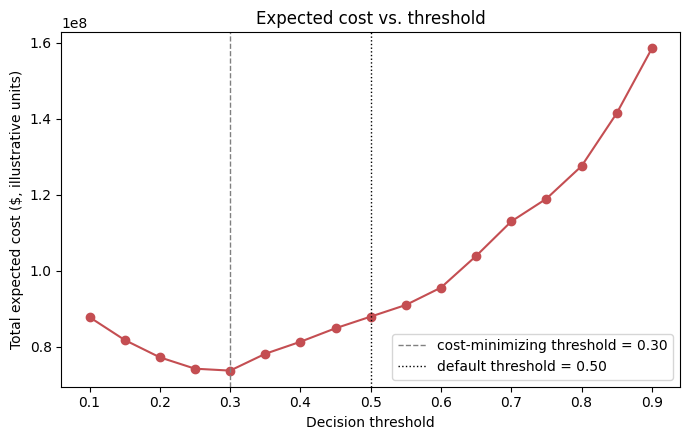

cost-minimizing threshold: 0.3


In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sweep["threshold"], sweep["total_cost"], marker="o", color="#C44E52")
best_row = sweep.loc[sweep["total_cost"].idxmin()]
ax.axvline(best_row["threshold"], linestyle="--", color="gray", linewidth=1,
           label=f"cost-minimizing threshold = {best_row['threshold']:.2f}")
ax.axvline(0.5, linestyle=":", color="black", linewidth=1, label="default threshold = 0.50")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Total expected cost ($, illustrative units)")
ax.set_title("Expected cost vs. threshold")
ax.legend()
plt.tight_layout()
plt.show()

OPTIMAL_THRESHOLD = float(best_row["threshold"])
print("cost-minimizing threshold:", OPTIMAL_THRESHOLD)

### Precision / recall / F1 at the optimal threshold vs. 0.5

In [6]:
def metrics_at(threshold):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
    }

comparison = pd.DataFrame([metrics_at(OPTIMAL_THRESHOLD), metrics_at(0.5)])
comparison

,threshold,precision,recall,f1
0,0.3,0.333333,0.819141,0.473845
1,0.5,0.514576,0.571967,0.541756


**Why the optimal threshold differs from 0.5:** With FN set to ~$130,110 (average exposure per missed defaulter) and FP at ~$19,516 (15% of that), missing a defaulter is **6.7x costlier** than wrongly flagging a good customer. The cost curve bottoms out at **threshold = 0.30**, well below 0.5's default — cost there (~$73.7M) is meaningfully lower than at 0.5 (~$87.9M). At 0.30 the model trades precision for recall on purpose: recall jumps from 0.572 to 0.819 (catching far more actual defaulters) while precision drops from 0.515 to 0.333 (more good customers get flagged). Given the cost asymmetry, that trade is worth it in expected-cost terms — a lower bar for flagging risk is cheaper than letting more real defaults slip through.

## Part B — Fairness audit
At the cost-optimal threshold chosen above, checking approval rate, false negative rate (missed defaulters), and false positive rate (wrongly flagged good customers), split by `SEX` and `EDUCATION` — the categorical breakdowns tagged for this purpose back in Phase 2.

In [7]:
audit_df = X_test_raw.copy()
audit_df = clean_categoricals(audit_df)  # same EDUCATION/MARRIAGE cleanup the model itself uses
audit_df["y_true"] = y_test.values
audit_df["y_pred"] = (y_proba >= OPTIMAL_THRESHOLD).astype(int)

def group_fairness_metrics(frame, group_col):
    rows = []
    for group_value, sub in frame.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(sub["y_true"], sub["y_pred"], labels=[0, 1]).ravel()
        rows.append({
            group_col: group_value,
            "n": len(sub),
            "approval_rate": (sub["y_pred"] == 0).mean(),  # predicted non-default = "approved"
            "FNR": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "FPR": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
        })
    return pd.DataFrame(rows)

sex_labels = {1: "Male", 2: "Female"}
audit_df["SEX_label"] = audit_df["SEX"].map(sex_labels)
sex_fairness = group_fairness_metrics(audit_df, "SEX_label")
sex_fairness

,SEX_label,n,approval_rate,FNR,FPR
0,Female,3598,0.484158,0.197128,0.438206
1,Male,2402,0.415071,0.158645,0.506790


In [8]:
education_labels = {1: "Grad school", 2: "University", 3: "High school", 4: "Others"}
audit_df["EDUCATION_label"] = audit_df["EDUCATION"].map(education_labels)
education_fairness = group_fairness_metrics(audit_df, "EDUCATION_label")
education_fairness

,EDUCATION_label,n,approval_rate,FNR,FPR
0,Grad school,2130,0.555869,0.219753,0.365217
1,High school,1014,0.372781,0.172414,0.557769
2,Others,82,0.634146,0.400000,0.350649
3,University,2774,0.405552,0.158537,0.517941


### Disparate impact ratio (SEX)
Four-fifths rule: flag if the lower-approval-rate group's approval rate is below 80% of the higher-approval-rate group's.

In [9]:
rates = sex_fairness.set_index("SEX_label")["approval_rate"]
di_ratio = rates.min() / rates.max()
lower_group = rates.idxmin()
higher_group = rates.idxmax()

print(f"{lower_group} approval rate: {rates[lower_group]:.4f}")
print(f"{higher_group} approval rate: {rates[higher_group]:.4f}")
print(f"disparate impact ratio: {di_ratio:.4f}")
print("FLAGGED — below the 80% four-fifths threshold" if di_ratio < 0.8 else "within the 80% four-fifths threshold")

Male approval rate: 0.4151
Female approval rate: 0.4842
disparate impact ratio: 0.8573
within the 80% four-fifths threshold


### Interpretation

At the cost-optimal threshold (0.30), the **SEX** disparate impact ratio is **0.857** (male approval 41.5% vs. female approval 48.4%) — technically inside the 80% four-fifths rule, but close enough to the line that it shouldn't be waved off, especially since FPR is meaningfully higher for males (50.7% vs. 43.8%) — men are more often wrongly flagged as risky at this threshold. **EDUCATION** shows a wider spread: approval ranges from 37.3% (high school) to 63.4% ("Others"), though the "Others" group is only 82 test rows (the undocumented 0/5/6 codes folded together in Phase 3), so that number is noisy and shouldn't be over-read.

**This is not a general claim about lending fairness.** The dataset is a snapshot of one Taiwanese bank's cardholders from 2005 — the group differences reported here describe this benchmark dataset and this model, not lending practice broadly, and 6,000 test rows (especially split into four EDUCATION buckets) is a small sample for high-confidence disparity claims.

**What a real deployment would need to check further:** whether `EDUCATION` or `MARRIAGE` acts as a proxy for `SEX` or another protected attribute (i.e., check the correlation between `EDUCATION` and `LIMIT_BAL`/`SEX` directly, not just each one's marginal relationship with the target); whether the FPR gap by sex persists across other thresholds, not just this one; and whether the underlying *training* data itself reflects historically biased approval decisions the model would then be reproducing rather than correcting.

## Save the production threshold to `model_info.json`

In [10]:
info_path = MODEL_DIR / "model_info.json"
with open(info_path) as f:
    model_info = json.load(f)

model_info["production_threshold"] = OPTIMAL_THRESHOLD

with open(info_path, "w") as f:
    json.dump(model_info, f, indent=2)

print(f"production_threshold = {OPTIMAL_THRESHOLD} saved to {info_path}")

production_threshold = 0.3 saved to ../model/model_info.json


## Summary

- Cost-optimal threshold: **0.30** (vs. the naive 0.5 default), chosen by minimizing expected cost under a 6.7x FN:FP cost ratio — saved to `model/model_info.json` as `production_threshold`.
- At 0.30 the model catches far more defaulters (recall 0.819 vs. 0.572 at 0.5) at the deliberate cost of more false positives (precision 0.333 vs. 0.515) — the right trade when missing a default is this much more expensive than over-flagging a good customer.
- Fairness audit at 0.30: SEX disparate impact ratio is 0.857 — within the four-fifths rule but close to it, with a notably higher false-positive rate for males (50.7% vs. 43.8%) worth monitoring.
- EDUCATION shows the widest approval-rate spread (37.3%–63.4%), but the smallest group ("Others", n=82) is too small to draw firm conclusions from.
- These findings describe this specific benchmark dataset and model only — a real deployment would need to check for proxy effects (EDUCATION/LIMIT_BAL vs. SEX), re-check the disparity across thresholds, and examine whether the historical labels themselves encode bias.